## EDA

In [1]:
!git clone https://github.com/ryanzhumich/AESLC.git

Cloning into 'AESLC'...
remote: Enumerating objects: 17469, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 17469 (delta 1), reused 0 (delta 0), pack-reused 17461 (from 1)
Receiving objects: 100% (17469/17469), 7.36 MiB | 8.61 MiB/s, done.
Resolving deltas: 100% (48/48), done.
Updating files: 100% (18304/18304), done.


In [2]:
import os
import pandas as pd
import string
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_dir = '/content/AESLC/enron_subject_line/train'
file_name = os.listdir(file_dir)[2]
file_path = os.path.join(file_dir, file_name)
with open(file_path, "r") as f:
  text = f.read()
  print(text)

Darron:   I got your message, but I must have missed you.
Try calling Debbie Delgado @ x39183.
She is the ADMIN who sits next to me.
If you want to just call Kai directly about mortgages, his vital signs are below (just kidding).
The best place to reach him is at 713-816-1300.

@subject
I have moved, but my Phone has not .....


In [4]:
def clean_text(text):
  text = text.lower() # lower case
  text = text.replace('\n',' ') # removing \n
  remove_punc = str.maketrans('', '', string.punctuation)
  text = text.translate(remove_punc) # removing special characters
  text = ' '.join(text.split()) # removing unneccessary space
  return text

emails = []
subjects = []
email_id = []
file_dir = '/content/AESLC/enron_subject_line/train'
for file_name in os.listdir(file_dir):
  file_path = os.path.join(file_dir, file_name)
  with open(file_path, "r") as f:
    text = f.read()
    email_contents,subject = text.split('@subject\n')
    email_sentences = email_contents.split('\n')
    email_sentences = [clean_text(sentence) for sentence in email_sentences if clean_text(sentence) not in [' ','']]
    subject = clean_text(subject)
    emails.append(email_sentences)
    subjects.append(subject)

In [5]:
mail_sub_data = pd.DataFrame({'email':emails,'subject':subjects})

In [6]:
mail_sub_data

,email,subject
0,[the information contained herein is based on ...,clm02clm03 spread
1,[dear mr skilling please accept my invitation ...,carlton woods
2,[darron i got your message but i must have mis...,i have moved but my phone has not
3,[a conference call has been scheduled for thur...,measurement detail
4,[i just received this update from our good fri...,blazer ticket specials for ena employees
...,...,...
14431,[after a careful review of the wholesale and r...,logistics commercial realignment
14432,"[kim great catching up with you today, as prom...",opportunities
14433,"[im soooo good, the chosen path was cool indif...",we have closure well sortof
14434,"[i just spoke with the lawyer, we cant do anyt...",probate


## Email word length

In [6]:
email_word_length = []
subject_word_length = []

for _,mail_data in mail_sub_data.iterrows():
  count = 0
  for sentence in mail_data['email']:
    count += len(sentence.split())
  email_word_length.append(count)
  count = 0
  count += len(mail_data['subject'].split())
  subject_word_length.append(count)
mail_sub_data['email_word_length'] = email_word_length
mail_sub_data['subject_word_length'] = subject_word_length

In [ ]:
mail_sub_data['email_word_length'].max()

3125

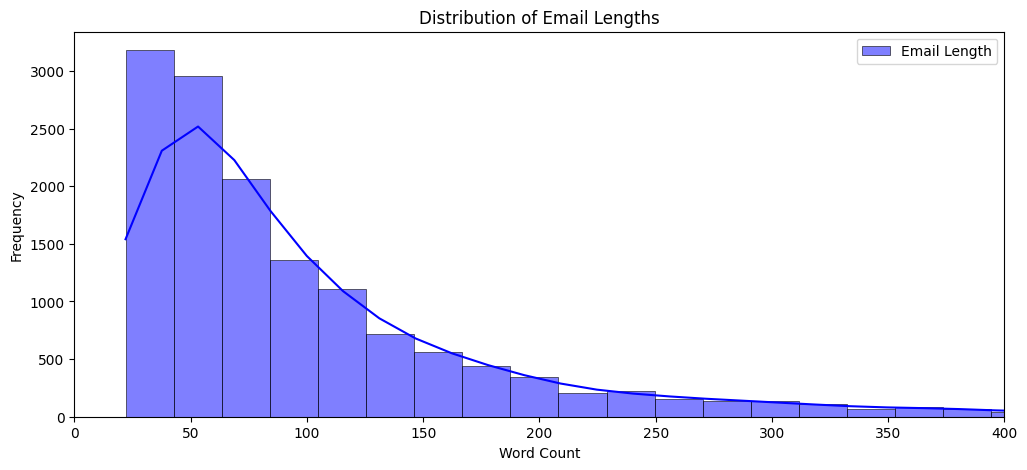

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(mail_sub_data['email_word_length'], bins=150, kde=True, color="blue", label="Email Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(0,400)
plt.title("Distribution of Email Lengths")
plt.show()

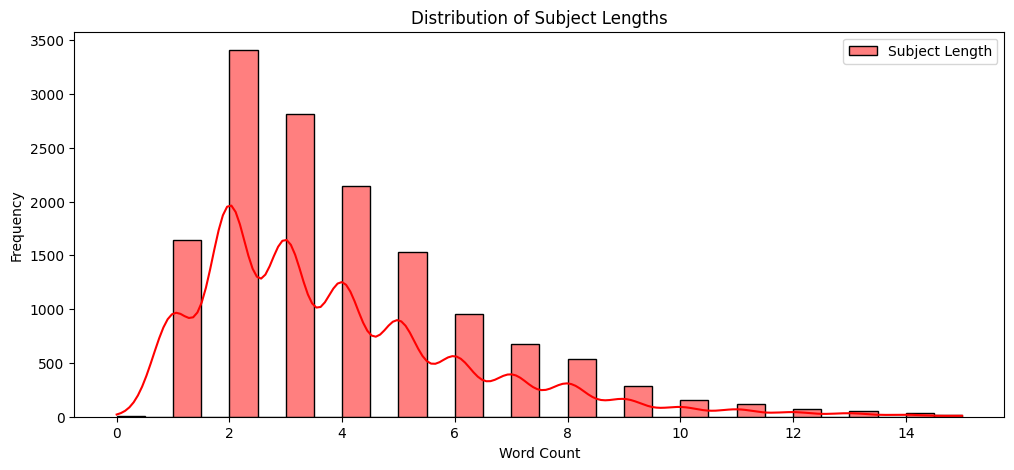

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(mail_sub_data['subject_word_length'], bins=30, kde=True, color="red", label="Subject Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.title("Distribution of Subject Lengths")
plt.show()

## Vocabulary

In [23]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import words as nltk_words

nltk.download('punkt_tab')
nltk.download('words')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [13]:
email_vocabulary = {}

for _,mail_data in mail_sub_data.iterrows():
  for sentence in mail_data['email']:
    words = word_tokenize(sentence)
    for word in words:
      if word in email_vocabulary:
        email_vocabulary[word] += 1
      else:
        email_vocabulary[word] = 1


In [14]:
subject_vocabulary = {}

for _,mail_data in mail_sub_data.iterrows():
  words = word_tokenize(mail_data['subject'])
  for word in words:
    if word in subject_vocabulary:
      subject_vocabulary[word] += 1
    else:
      subject_vocabulary[word] = 1

In [15]:
len(email_vocabulary) # total unique words in email

56108

In [16]:
len(subject_vocabulary) #total unique words in subject

9509

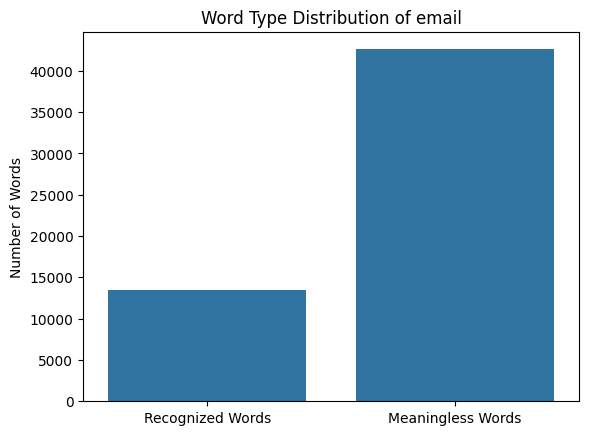

In [28]:
recognized_words = 0
meaningless_words = 0

english_words = set(nltk_words.words())
for word in list(email_vocabulary.keys()):
  if word not in english_words:
    meaningless_words +=1
  else:
    recognized_words +=1

labels = ['Recognized Words', 'Meaningless Words']
counts = [recognized_words, meaningless_words]


sns.barplot(x=labels, y=counts)
plt.title("Word Type Distribution of email")
plt.ylabel("Number of Words")
plt.show()

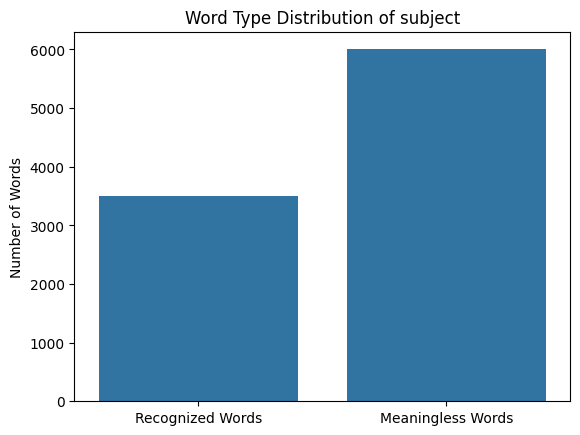

In [29]:
recognized_words = 0
meaningless_words = 0

for word in list(subject_vocabulary.keys()):
  if word not in english_words:
    meaningless_words +=1
  else:
    recognized_words +=1

labels = ['Recognized Words', 'Meaningless Words']
counts = [recognized_words, meaningless_words]


sns.barplot(x=labels, y=counts)
plt.title("Word Type Distribution of subject")
plt.ylabel("Number of Words")
plt.show()